# Environment Setup

In [1]:
import sys
import os

# Ensure project root is in path
sys.path.append(os.path.abspath(".."))

# Imports

In [2]:
import importlib
import pandas as pd
import matplotlib.pyplot as plt

import model.assumptions as assumptions_module
import model.policy as policy_module
import model.projection as projection_module
import model.valuation as valuation_module
import model.results as results_module
import model.analysis.profit as profit_analysis

plt.style.use("seaborn-v0_8")

# Reload Modules

In [3]:
def reload_all():

    importlib.reload(assumptions_module)
    importlib.reload(policy_module)
    importlib.reload(projection_module)
    importlib.reload(results_module)
    importlib.reload(valuation_module)
    importlib.reload(profit_analysis)

reload_all()

# Notebook Entry Points 
import model.valuation as valuation 
import model.analysis.profit as profit_analysis 
import model.assumptions as assumptions_module 
import model.policy as policy_module

# Assumptions Setup

In [4]:
mortality = assumptions_module.load_mortality_table(
    "../data/mortality_tables/ons_mortality.csv"
)

interest = assumptions_module.FlatYieldCurve(
    interest_rate=0.03
)

lapse_table = assumptions_module.load_lapse_table(
    "../data/lapse_rates.csv"
)

assumptions = assumptions_module.AssumptionSet(
    mortality=mortality,
    interest=interest,
    lapse=lapse_table
)

# Single Policy Setup

In [ ]:
policy = policy_module.Policy(
    age=30,
    term=20,
    sum_assured=100000,
    premium=5000,
    gender="F",
    smoker_status="Non-Smoker",
    product_type="Term"
)

# Projection Analysis

In [ ]:
projection = projection_module.project_cashflows(
    policy,
    assumptions
)

projection

projection.rows[5]

ProjectionRow(t=5, age=35, prob_inforce=0.745801, qx=0.001110)

# Run valuation

In [7]:
valuation_result = valuation_module.value_policy(
    policy,
    assumptions,
    return_breakdown=True
)

# Core results

In [8]:
summary = {
    "PV Premiums": valuation_result.pv_premiums,
    "PV Claims": valuation_result.pv_claims,
    "Net Value": valuation_result.net_value
}

pd.Series(summary)

PV Premiums    54088.529257
PV Claims       1616.665936
Net Value      52471.863322
dtype: float64

# Build Analysis Dataset

In [9]:
df = profit_analysis.build_profit_dataframe(valuation_result)
df = profit_analysis.add_profit_signature(df)

# Profit Emergence Table

In [10]:
df[["t",
    "net_cashflow",
    "cum_cashflow",
    "pv_net",
    "cum_profit"
]].round(2)

,t,net_cashflow,cum_cashflow,pv_net,cum_profit
0,0,4923.10,4923.10,4923.10,4923.10
1,1,4518.30,9441.40,4386.70,9309.80
2,2,4285.68,13727.07,4039.66,13349.46
3,3,4061.91,17788.98,3717.22,17066.67
4,4,3848.43,21637.41,3419.28,20485.96
5,5,3646.22,25283.63,3145.26,23631.22
6,6,3523.90,28807.53,2951.21,26582.43
7,7,3408.80,32216.33,2771.67,29354.10
8,8,3297.68,35514.01,2603.22,31957.31
9,9,3184.57,38698.58,2440.71,34398.03


# Profit Signature

In [11]:
df[["t", "pv_net", "profit_pct"]].round(4)

,t,pv_net,profit_pct
0,0,4923.1000,0.0938
1,1,4386.6953,0.0836
2,2,4039.6598,0.0770
3,3,3717.2195,0.0708
4,4,3419.2829,0.0652
5,5,3145.2636,0.0599
6,6,2951.2112,0.0562
7,7,2771.6650,0.0528
8,8,2603.2176,0.0496
9,9,2440.7111,0.0465


# Summary Metrics

In [12]:
pd.Series(profit_analysis.summary_metrics(df))

total_pv_profit      52471.863322
total_cash_profit    66167.925964
peak_profit_year         0.000000
dtype: float64

# Visualisations

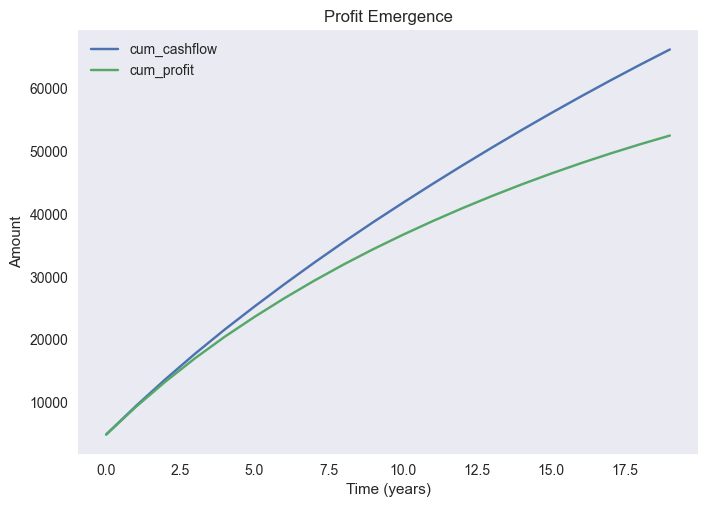

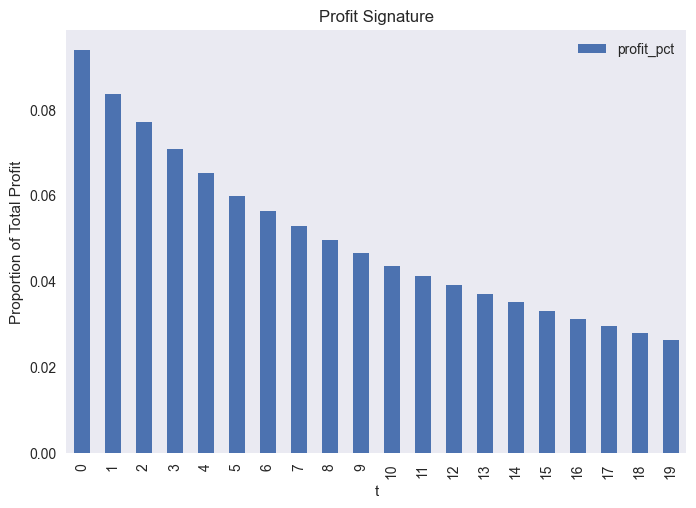

In [13]:
# Profit Emergence

df.plot(x="t", y=["cum_cashflow", "cum_profit"])
plt.title("Profit Emergence")
plt.ylabel("Amount")
plt.xlabel("Time (years)")
plt.grid()
plt.show()


# Profit Signature

df.plot(x="t", y="profit_pct", kind="bar")
plt.title("Profit Signature")
plt.ylabel("Proportion of Total Profit")
plt.grid()
plt.show()